# **Restaurant Rating Prediction**
## **Objective**:
#### Build a machine learning model to predict the Aggregate Rating of a restaurant using various features.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [5]:
df=pd.read_csv("C:\\Users\\sambh\\Desktop\\restaurant_project\\Dataset .csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [6]:
print("="*60)
print("STEP 2: DATA OVERVIEW")
print("="*60)
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

STEP 2: DATA OVERVIEW
Shape: (9551, 21)

First 5 rows:
   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  E

In [7]:
# ─────────────────────────────────────────────────────────────────
# STEP 3 ─ DATA CLEANING
# ─────────────────────────────────────────────────────────────────
# WHY we drop these columns:
#   Restaurant ID / Name  → unique identifiers, no predictive signal
#   Longitude / Latitude  → raw coords are noisy; city captures location signal
#   Address / Locality    → high-cardinality free text, hard to encode
#   Rating color          → this is derived FROM the rating, so it leaks the target
# ─────────────────────────────────────────────────────────────────

In [8]:
COLS_TO_DROP = [
    'Restaurant ID', 'Restaurant Name',
    'Longitude', 'Latitude',
    'Address', 'Locality', 'Locality Verbose',
    'Rating color', 'Rating text'
]

In [9]:
df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns], inplace =True)

In [10]:
df['Cuisines']= df['Cuisines'].fillna("Unknown")

In [11]:
df=df[df['Votes']>0].copy()

In [12]:
print("\n" + "="*60)
print("STEP 3: AFTER CLEANING")
print("="*60)
print(f"Shape after cleaning: {df.shape}")


STEP 3: AFTER CLEANING
Shape after cleaning: (8457, 12)


In [13]:
df['Log_Votes']= np.log1p(df['Votes'])
#log(1 + votes), safe for 0

In [14]:
TARGET= 'Aggregate rating'
NUMERIC_FEATURES= df.select_dtypes(include=['int64', 'float64']).columns.tolist()
NUMERIC_FEATURES= [c for c in NUMERIC_FEATURES if c!=TARGET ]
CATEGORICAL_FEATURES = df.select_dtypes(include=['object']).columns.tolist()


In [15]:
print("\n" + "="*60)
print("STEP 4: FEATURE OVERVIEW")
print("="*60)
print(f"Numeric features   : {NUMERIC_FEATURES}")
print(f"Categorical features: {CATEGORICAL_FEATURES}")


STEP 4: FEATURE OVERVIEW
Numeric features   : ['Country Code', 'Average Cost for two', 'Price range', 'Votes', 'Log_Votes']
Categorical features: ['City', 'Cuisines', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu']


In [16]:
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

In [17]:
# ─────────────────────────────────────────────────────────────────
# STEP 6 ─ PREPROCESSING PIPELINE 
# ─────────────────────────────────────────────────────────────────
# WHY a Pipeline instead of manual encoding?
#   1. Prevents data leakage — fit only on training data, transform both
#   2. One object to save/load for Streamlit — avoids encoder mismatch
#   3. Handles unseen categories in production automatically
#
# WHY SimpleImputer?
#   In case future data has NaN values we haven't seen yet
#
# WHY OneHotEncoder with handle_unknown='ignore'?
#   A restaurant in Streamlit may enter a city not in training data;
#   'ignore' turns unknown categories into all-zero vectors instead of crashing
# ─────────────────────────────────────────────────────────────────

In [18]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    # NOTE: We do NOT scale for Random Forest — tree models are scale-invariant.
    # If you switch to Ridge/SVR, add StandardScaler() here.
])

In [19]:
categorical_transformer = Pipeline(steps=[
    ('imputer',  SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot',   OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

In [20]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,   NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES),
])

In [21]:
#Use it for pipelline Diagram
from sklearn import set_config

In [22]:
set_config(display="diagram")

In [23]:
numeric_transformer

,steps,"[('imputer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [24]:
categorical_transformer

,steps,"[('imputer', ...), ('onehot', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'constant'
,fill_value,'Unknown'
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


In [25]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [26]:
# ─────────────────────────────────────────────────────────────────
# STEP 7 ─ TRAIN / TEST SPLIT
# ─────────────────────────────────────────────────────────────────
# WHY 80/20 split?
#   20% held-out test data gives a reliable out-of-sample estimate.
#   random_state=42 makes the split reproducible.
# ─────────────────────────────────────────────────────────────────

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")


Train size: 6765  |  Test size: 1692


In [28]:
# ─────────────────────────────────────────────────────────────────
# STEP 8 ─ MODEL COMPARISON  ← NEW
# ─────────────────────────────────────────────────────────────────
# WHY compare multiple models?
#   Different algorithms make different assumptions.  We pick the best
#   one via cross-validation, not just test-set performance (avoids
#   accidentally overfitting to our specific test split).
#
# Models tried:
#   LinearRegression  → baseline; assumes a linear relationship
#   Ridge             → linear + L2 regularisation; better when features correlated
#   DecisionTree      → non-linear, single tree; tends to overfit
#   RandomForest      → ensemble of trees; reduces overfitting via averaging
#   GradientBoosting  → sequential ensemble; often best accuracy but slower
# ─────────────────────────────────────────────────────────────────

In [29]:
MODELS ={
    "Linear Regression": LinearRegression(),
    "Ridge Regression" : Ridge(alpha=1.0),
    "Decision Tree" : DecisionTreeRegressor(random_state=42),
    "Random Forest" : RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=100, random_state=42),
    }

In [30]:
print("\n" + "="*60)
print("STEP 8 : MODEL COMPARISON(5- fold Cross-Validation R²)")
print("\n" + "="*60)


STEP 8 : MODEL COMPARISON(5- fold Cross-Validation R²)



In [31]:
results ={}
for name, model in MODELS.items():
    pipe = Pipeline(steps=[('prep', preprocessor), ('model', model)])
    cv_scores= cross_val_score(pipe, X_train, y_train,cv=5, scoring='r2', n_jobs=-1)

    results[name] = cv_scores
    print(f"{name:<25} CV R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
best_model_name = max(results, key=lambda k: results[k].mean())
print(f"\n✅ Best model: {best_model_name}")

Linear Regression         CV R² = 0.2969 ± 0.6261
Ridge Regression          CV R² = 0.6281 ± 0.0080
Decision Tree             CV R² = 0.8810 ± 0.0053
Random Forest             CV R² = 0.9257 ± 0.0029
Gradient Boosting         CV R² = 0.9247 ± 0.0030

✅ Best model: Random Forest


In [32]:
# ─────────────────────────────────────────────────────────────────
# STEP 9 ─ HYPERPARAMETER TUNING FOR RANDOM FOREST  ← NEW
# ─────────────────────────────────────────────────────────────────
# WHY RandomizedSearchCV instead of GridSearchCV?
#   GridSearchCV tries every combination — exponential time.
#   RandomizedSearchCV samples n_iter random combos — faster, nearly as good.
#
# WHY tune these params?
#   n_estimators    → more trees = lower variance but slower
#   max_depth       → depth limit prevents overfitting
#   min_samples_split → minimum data points to split a node
#   max_features    → number of features to consider per split (controls diversity)
# ─────────────────────────────────────────────────────────────────

In [33]:
param_dist = {
    'model__n_estimators':     [100, 200, 300],
    'model__max_depth':        [None, 10, 20, 30],
    'model__min_samples_split':[2, 5, 10],
    'model__max_features':     ['sqrt', 'log2', 0.5],
}
rf_pipeline = Pipeline(steps=[
    ('prep',  preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1)),
])

In [34]:
print("\n" + "="*60)
print("STEP 9: HYPERPARAMETER TUNING (Random Forest)")
print("="*60)



STEP 9: HYPERPARAMETER TUNING (Random Forest)


In [35]:
search = RandomizedSearchCV(
    rf_pipeline, param_distributions=param_dist,
    n_iter=15, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1,
)
search.fit(X_train, y_train)
print(f"\nBest params : {search.best_params_}")
print(f"Best CV R²  : {search.best_score_:.4f}")

best_pipeline = search.best_estimator_

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best params : {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__max_features': 0.5, 'model__max_depth': 20}
Best CV R²  : 0.9287


In [36]:
# ─────────────────────────────────────────────────────────────────
# STEP 10 ─ FINAL EVALUATION ON TEST SET
# ─────────────────────────────────────────────────────────────────
# WHY these 3 metrics?
#   RMSE  → same unit as rating (e.g. ±0.2 stars); penalises big errors more
#   MAE   → average absolute error; easier to interpret
#   R²    → proportion of variance explained; 1.0 is perfect
# ─────────────────────────────────────────────────────────────────

In [37]:
y_pred = best_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("\n" + "="*60)
print("STEP 10: FINAL TEST SET METRICS")
print("="*60)
print(f"  RMSE  : {rmse:.4f}")
print(f"  MAE   : {mae:.4f}")
print(f"  R²    : {r2:.4f}")


STEP 10: FINAL TEST SET METRICS
  RMSE  : 0.3300
  MAE   : 0.2288
  R²    : 0.9286


In [38]:
# ─────────────────────────────────────────────────────────────────
# STEP 11 ─ PLOTS
# ─────────────────────────────────────────────────────────────────

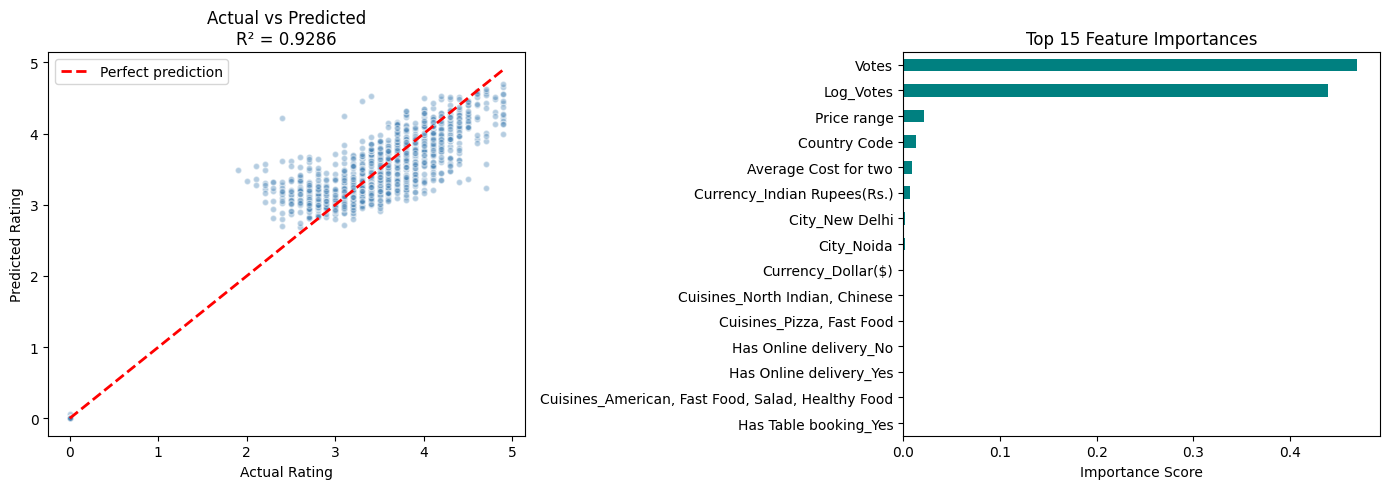


Plot saved to model_evaluation.png


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Actual vs Predicted ──
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='white', s=20)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel("Actual Rating")
axes[0].set_ylabel("Predicted Rating")
axes[0].set_title(f"Actual vs Predicted\nR² = {r2:.4f}")
axes[0].legend()



# ── Plot 2: Feature Importance ──
rf_model = best_pipeline.named_steps['model']
ohe_cols = best_pipeline.named_steps['prep'] \
               .named_transformers_['cat'] \
               .named_steps['onehot'] \
               .get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_feature_names = NUMERIC_FEATURES + ohe_cols

importances = pd.Series(rf_model.feature_importances_, index=all_feature_names)
top15 = importances.nlargest(15)
top15.sort_values().plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title("Top 15 Feature Importances")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150)
plt.show()
print("\nPlot saved to model_evaluation.png")

In [45]:
# ─────────────────────────────────────────────────────────────────
# STEP 12 ─ SAVE THE PIPELINE  ← USED BY STREAMLIT
# ─────────────────────────────────────────────────────────────────
# WHY save the whole pipeline (not just the model)?
#   The pipeline includes the preprocessor (imputer + encoder).
#   If we only saved the model, we'd have to manually reproduce the
#   exact same encoding in Streamlit — extremely error-prone.
#   Saving the pipeline guarantees identical transformations.
# ─────────────────────────────────────────────────────────────────

In [52]:
MODEL_PATH = "restaurant_rating_pipeline.joblib"
joblib.dump(best_pipeline, MODEL_PATH)
print(f"\n✅ Pipeline saved → {MODEL_PATH}")

# Also save the feature columns so Streamlit can build the input form
FEATURE_META = {
    'numeric_features':     NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'unique_values': {
        col: sorted(df[col].dropna().unique().tolist())
        for col in CATEGORICAL_FEATURES
    }
}
joblib.dump(FEATURE_META, "feature_meta.joblib")
print("✅ Feature metadata saved → feature_meta.joblib")



✅ Pipeline saved → restaurant_rating_pipeline.joblib
✅ Feature metadata saved → feature_meta.joblib
